In [1]:
import pandas as pd

# Create dataset
data = {
    "Hours": [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0],
    "Scores": [35, 40, 45, 50, 55, 60, 62, 65, 70, 75, 78, 80, 85, 88, 90, 95]
}

df = pd.DataFrame(data)
df.to_csv("student_scores.csv", index=False)

print("Dataset saved as student_scores.csv")
df.head()


Dataset saved as student_scores.csv


,Hours,Scores
0,1.5,35
1,2.0,40
2,2.5,45
3,3.0,50
4,3.5,55


           Hours     Scores
count  16.000000  16.000000
mean    5.250000  67.062500
std     2.380476  18.599171
min     1.500000  35.000000
25%     3.375000  53.750000
50%     5.250000  67.500000
75%     7.125000  81.250000
max     9.000000  95.000000


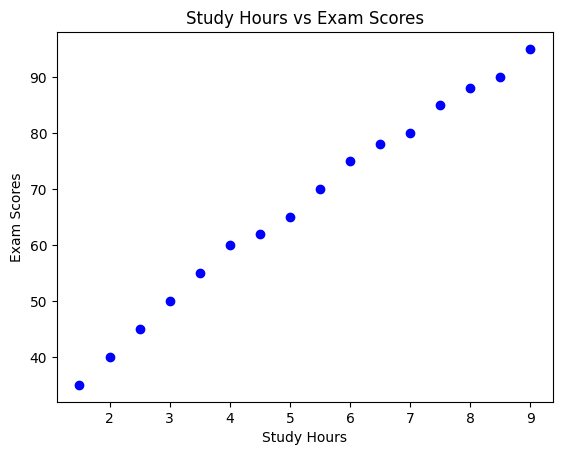

In [2]:
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_scores.csv")

# Quick look
print(df.describe())

# Visualize correlation
plt.scatter(df["Hours"], df["Scores"], color="blue")
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Study Hours vs Exam Scores")
plt.show()


R²: 0.9830180902939857
MAE: 2.7265342960288823
RMSE: 2.816688825692073


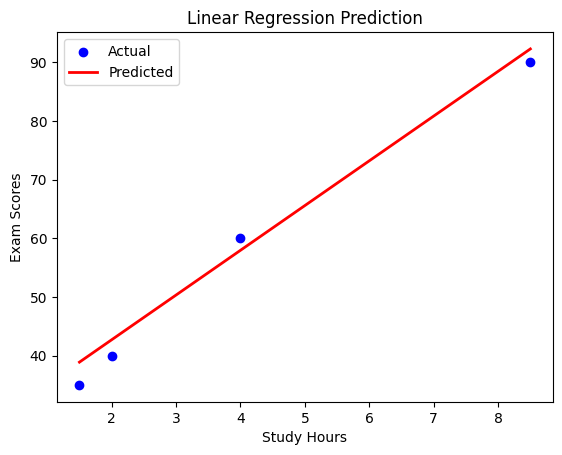

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split data
X = df[["Hours"]]
y = df["Scores"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot regression line
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted")
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Linear Regression Prediction")
plt.legend()
plt.show()


Polynomial R²: 0.9946493166588158
Polynomial MAE: 1.5599172115608937
Polynomial RMSE: 1.5810668466132272


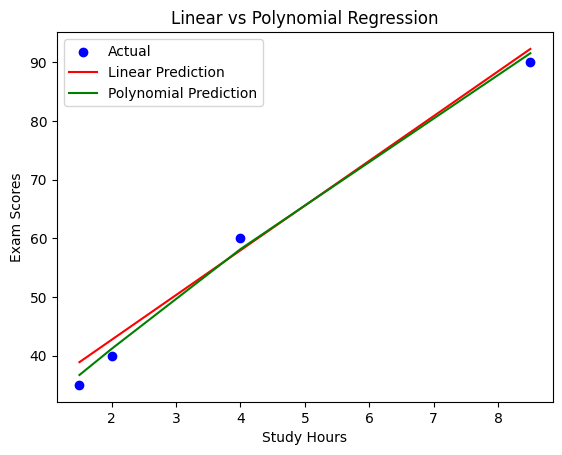

In [4]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial transformation (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)

# Train polynomial regression
poly_model = LinearRegression()
poly_model.fit(X_poly, y_train)

# Predictions
X_test_poly = poly.transform(X_test)
y_poly_pred = poly_model.predict(X_test_poly)

# Evaluation
print("Polynomial R²:", r2_score(y_test, y_poly_pred))
print("Polynomial MAE:", mean_absolute_error(y_test, y_poly_pred))
print("Polynomial RMSE:", np.sqrt(mean_squared_error(y_test, y_poly_pred)))

# Plot comparison
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", label="Linear Prediction")
plt.plot(X_test, y_poly_pred, color="green", label="Polynomial Prediction")
plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()


In [10]:
import getpass
ngrok_key = getpass.getpass("Enter ngrok key:")

Enter ngrok key:··········


In [11]:
!pip install streamlit pyngrok

In [12]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset
data = {
    "Hours": [1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0],
    "Scores": [35,40,45,50,55,60,62,65,70,75,78,80,85,88,90,95]
}
df = pd.DataFrame(data)

# Train linear regression
X = df[["Hours"]]
y = df["Scores"]
linear_model = LinearRegression()
linear_model.fit(X, y)

# Train polynomial regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Predictions for metrics
y_linear_pred = linear_model.predict(X)
y_poly_pred = poly_model.predict(X_poly)

# Streamlit UI
st.title("📘 Student Score Predictor")
st.write("Predict exam scores based on study hours using Linear or Polynomial Regression.")

# User input
hours = st.slider("Select study hours:", 1.0, 10.0, 5.0)
model_choice = st.radio("Choose regression model:", ["Linear", "Polynomial"])

# Prediction
if model_choice == "Linear":
    predicted_score = linear_model.predict([[hours]])[0]
else:
    predicted_score = poly_model.predict(poly.transform([[hours]]))[0]

st.write(f"Predicted Exam Score for {hours} hours: **{predicted_score:.2f}**")

# Metrics Dashboard
st.subheader("📊 Model Performance Metrics")
metrics = {
    "Linear Regression": {
        "R²": r2_score(y, y_linear_pred),
        "MAE": mean_absolute_error(y, y_linear_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_linear_pred))
    },
    "Polynomial Regression": {
        "R²": r2_score(y, y_poly_pred),
        "MAE": mean_absolute_error(y, y_poly_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_poly_pred))
    }
}
st.write(pd.DataFrame(metrics).T)

# Visualization
fig, ax = plt.subplots()
ax.scatter(X, y, color="blue", label="Actual Data")

X_range = np.linspace(1, 10, 100).reshape(-1, 1)
ax.plot(X_range, linear_model.predict(X_range), color="red", label="Linear Fit")
ax.plot(X_range, poly_model.predict(poly.transform(X_range)), color="green", label="Polynomial Fit")

ax.set_xlabel("Study Hours")
ax.set_ylabel("Exam Scores")
ax.set_title("Regression Comparison")
ax.legend()
st.pyplot(fig)


Overwriting app.py


In [13]:
from pyngrok import ngrok

port = 8501

ngrok.set_auth_token(ngrok_key)
ngrok.connect(port).public_url

'https://channing-semicommunicative-cristopher.ngrok-free.dev'

In [14]:
!rm -rf logs.txt && streamlit run app.py &>/content/logs.txt